In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [46]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 48)


In [47]:
df_map = df_map.copy()

In [48]:
# import pandas as pd
# import numpy as np
# import folium
# from folium.plugins import MarkerCluster
# from datetime import datetime

# # =============================
# # 1️⃣ Limpeza e Padronização (O Pulo do Gato)
# # =============================


# # Função para garantir que a BR seja uma string limpa (ex: "116")
# def limpar_br(df):
#     return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# df_map["br"] = limpar_br(df_map)

# # Limpeza de coordenadas e KM
# cols = ["latitude", "longitude", "km"]
# for col in cols:
#     df_map[col] = pd.to_numeric(df_map[col].astype(str).str.replace(",", "."), errors="coerce")

# df_map = df_map.dropna(subset=["latitude", "longitude", "km"])
# df_map["km_bin"] = (df_map["km"] // 5) * 5

# # =============================
# # 2️⃣ Agregação
# # =============================

# # Cálculo de severidade no DF original
# df_map["severity_index"] = (4 * df_map["mortos"] + 2 * df_map["feridos_graves"] + 1 * df_map["feridos_leves"])

# df_segmento = df_map.groupby(["br", "km_bin"]).agg(
#     severity_index=("severity_index", "mean"),
#     n_acidentes=("severity_index", "count"),
#     total_mortos=("mortos", "sum"),
#     total_feridos_graves=("feridos_graves", "sum"),
#     total_feridos_leves=("feridos_leves", "sum")
# ).reset_index()

# df_segmento["risk_score"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])
# df_segmento["taxa_mortalidade"] = df_segmento["total_mortos"] / df_segmento["n_acidentes"]

# def classificar_gravidade(row):
#     if row["total_mortos"] > 0: return "Acidente com mortos"
#     if (row["total_feridos_graves"] > 0) or (row["total_feridos_leves"] > 0): return "Sinistro de média gravidade"
#     return "Sinistro sem gravidade"

# df_segmento["gravidade"] = df_segmento.apply(classificar_gravidade, axis=1)

# # =============================
# # 3️⃣ Mapa e Plotagem
# # =============================

# m = folium.Map(
#     location=[df_map["latitude"].median(), df_map["longitude"].median()],
#     zoom_start=6,
#     #tiles="CartoDB positron" # Evita o erro 403 Access Blocked
# )

# # Camadas
# layers = {
#     "Acidente com mortos": MarkerCluster(name="🔴 Acidente com mortos").add_to(m),
#     "Sinistro de média gravidade": MarkerCluster(name="🟠 Média gravidade").add_to(m),
#     "Sinistro sem gravidade": MarkerCluster(name="🟢 Sem gravidade").add_to(m)
# }

# segmentos_grupo = df_map.groupby(["br", "km_bin"])

# for _, row in df_segmento.iterrows():
#     try:
#         # Busca o grupo usando as chaves limpas
#         grupo = segmentos_grupo.get_group((row["br"], row["km_bin"]))
#         lat, lon = grupo["latitude"].median(), grupo["longitude"].median()
#     except KeyError:
#         continue # Se não achar, pula

#     # Define cor
#     cor = "red" if row["gravidade"] == "Acidente com mortos" else "orange" if row["gravidade"] == "Sinistro de média gravidade" else "green"

#     # Popup
#     veiculos = grupo["tipo_veiculo"].value_counts().head(3)
#     veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

#     popup_html = f"""
#     <b>BR:</b> {row['br']} | <b>KM:</b> {row['km_bin']}<br>
#     <b>Gravidade:</b> {row['gravidade']}<br>
#     <b>Mortos:</b> {row['total_mortos']}<br>
#     <hr><b>Top Veículos:</b><br>{veiculo_txt}
#     """

#     # CircleMarker é melhor que Circle porque o tamanho é fixo em pixels
#     folium.CircleMarker(
#         location=[lat, lon],
#         radius=7 + (np.log1p(row["total_mortos"]) * 3),
#         color=cor,
#         fill=True,
#         fill_opacity=0.7,
#         popup=folium.Popup(popup_html, max_width=250)
#     ).add_to(layers[row["gravidade"]])

# folium.LayerControl().add_to(m)
# path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/Maps/mapa_risco_{datetime.now().strftime('%Y%m%d_%H%M')}.html"
# m.save(path)
# print(f"Mapa gerado com sucesso em: {path}")

In [ ]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# Limpeza da BR
# =============================

def limpar_br(df):
    return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

if br_escolhida.strip() != "":
    df_map = df_map[df_map["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_map.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()

# =============================
# Limpeza coordenadas
# =============================

cols = ["latitude", "longitude", "km"]

for col in cols:
    df_map[col] = pd.to_numeric(
        df_map[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

df_map = df_map.dropna(subset=["latitude", "longitude", "km"])

# =============================
# FILTRAR APENAS ACIDENTES COM MORTOS
# =============================

df_map = df_map[df_map["mortos"] > 0]

df_map["km_bin"] = (df_map["km"] // 5) * 5

# =============================
# Índice de severidade
# =============================

df_map["severity_index"] = (
    4 * df_map["mortos"] +
    2 * df_map["feridos_graves"] +
    1 * df_map["feridos_leves"]
)

# =============================
# Agrupar segmentos
# =============================

df_segmento = df_map.groupby(["br", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()

# =============================
# Classificação de veículos
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]

carros_leves = ["Automóvel"]

caminhonetes = [
    "Caminhonete",
    "Camioneta",
    "Utilitário"
]

motos = [
    "Motocicleta",
    "Motoneta"
]

ciclomotores = [
    "Ciclomotor",
    "Triciclo",
    "Quadriciclo"
]

# =============================
# Criar mapa
# =============================

m = folium.Map(
    location=[df_map["latitude"].median(), df_map["longitude"].median()],
    zoom_start=6
)

# =============================
# Camadas
# =============================

layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)

layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores / Triciclos").add_to(m)

segmentos_grupo = df_map.groupby(["br", "km_bin"])

# =============================
# Plotar pontos
# =============================

for _, row in df_segmento.iterrows():

    try:
        grupo = segmentos_grupo.get_group((row["br"], row["km_bin"]))
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
    tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
    tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
    tem_moto = grupo["tipo_veiculo"].isin(motos).any()
    tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()

    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
    <b>BR:</b> {row['br']} | <b>KM:</b> {row['km_bin']}<br>
    
    <b>Total de acidentes:</b> {row['n_acidentes']}<br>

    <b>Total de mortos:</b> {row['total_mortos']}<br>
    <hr>
    <b>Top Veículos:</b><br>{veiculo_txt}
    """

    radius = 7 + (np.log1p(row["total_mortos"]) * 3)

    # camada geral
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layer_todos)

    # caminhão
    if tem_caminhao:
        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="purple",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_caminhao)

    # automóveis
    if tem_carro:
        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="blue",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_carro)

    # caminhonetes
    if tem_caminhonete:
        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="darkgreen",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_caminhonete)

    # motos
    if tem_moto:
        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="orange",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_moto)

    # ciclomotores
    if tem_ciclomotor:
        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="black",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_ciclomotor)

# =============================
# Controle de camadas
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# Salvar mapa
# =============================

path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsCarro/mapa_mortos_{datetime.now().strftime('%Y%m%d_%H%M')}.html"

m.save(path)

print(f"Mapa gerado com sucesso em: {path}")

Mostrando todas as rodovias
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsCarro/mapa_mortos_20260316_1525.html


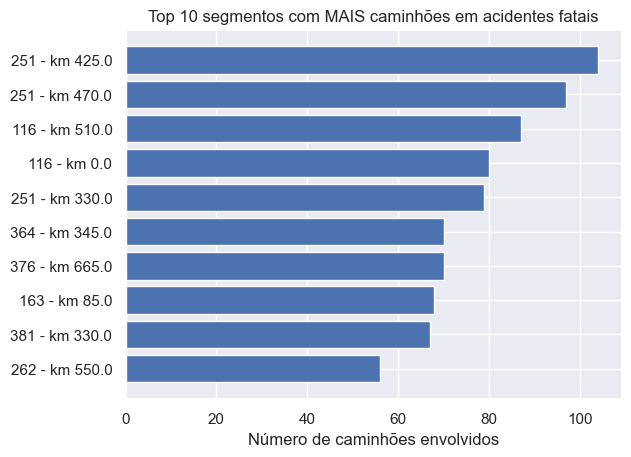

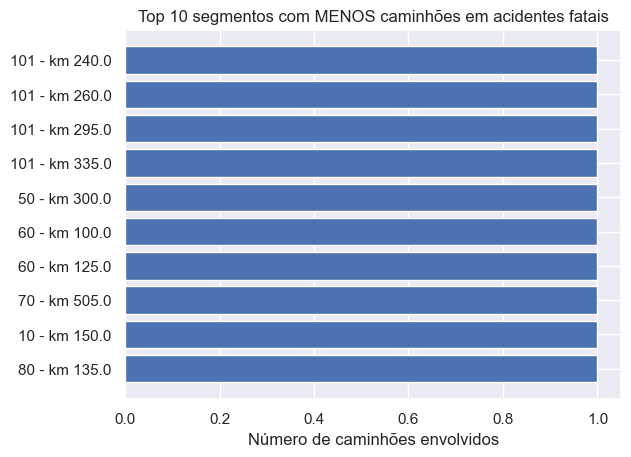

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# =============================
# 🚛 Veículos de caminhão
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]

# =============================
# 1️⃣ Filtrar acidentes com mortos
# =============================

df_mortos = df_map[df_map["mortos"] > 0].copy()

# =============================
# 2️⃣ Filtrar apenas caminhões
# =============================

df_caminhao = df_mortos[df_mortos["tipo_veiculo"].isin(caminhao)].copy()

# =============================
# 3️⃣ Contar caminhões por segmento
# =============================

df_caminhao_seg = df_caminhao.groupby(
    ["br", "km_bin"]
).size().reset_index(name="n_caminhoes")

# Criar nome do segmento
df_caminhao_seg["segmento"] = (
    df_caminhao_seg["br"].astype(str) +
    " - km " +
    df_caminhao_seg["km_bin"].astype(str)
)

# Ordenar
df_caminhao_seg = df_caminhao_seg.sort_values(
    "n_caminhoes",
    ascending=False
)

# =============================
# 4️⃣ Top 10 MAIS caminhões
# =============================

top10 = df_caminhao_seg.head(10)

plt.figure()

plt.barh(
    top10["segmento"],
    top10["n_caminhoes"]
)

plt.xlabel("Número de caminhões envolvidos")
plt.title("Top 10 segmentos com MAIS caminhões em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

# =============================
# 5️⃣ 10 MENOS caminhões
# =============================

menos10 = df_caminhao_seg.tail(10).sort_values("n_caminhoes")

plt.figure()

plt.barh(
    menos10["segmento"],
    menos10["n_caminhoes"]
)

plt.xlabel("Número de caminhões envolvidos")
plt.title("Top 10 segmentos com MENOS caminhões em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

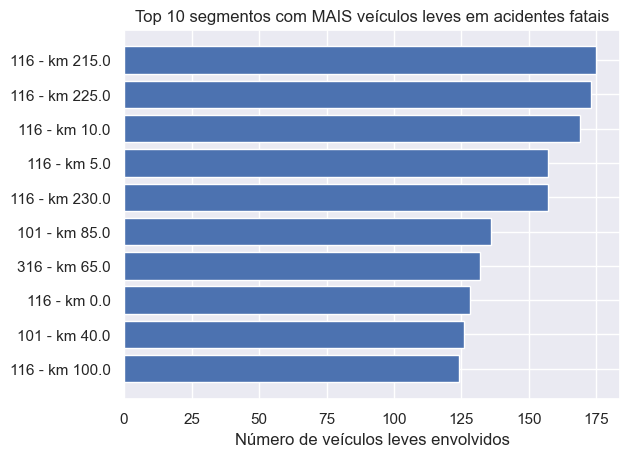

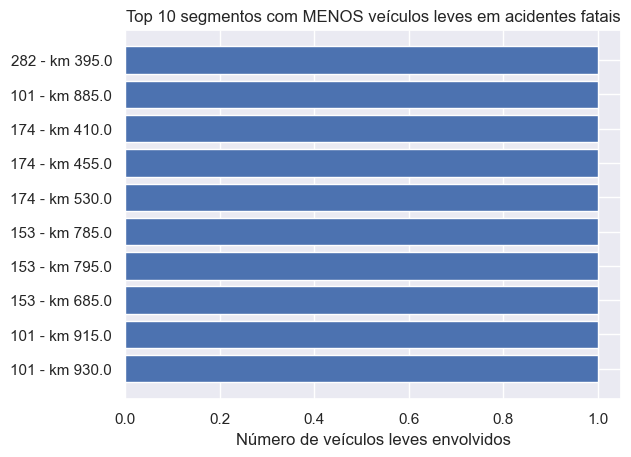

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# =============================
# 🚗 Veículos leves
# =============================

veiculos_leves = [
    "Automóvel",
    #
    "Caminhonete",
    "Camioneta",
    "Utilitário",
    #
    "Motocicleta",
    "Motoneta",
    #
    "Ciclomotor",
    "Triciclo",
    "Quadriciclo"
]

# =============================
# 1️⃣ Filtrar acidentes com mortos
# =============================

df_mortos = df_map[df_map["mortos"] > 0].copy()

# =============================
# 2️⃣ Filtrar apenas veículos leves
# =============================

df_leves = df_mortos[df_mortos["tipo_veiculo"].isin(veiculos_leves)].copy()

# =============================
# 3️⃣ Contar veículos leves por segmento
# =============================

df_leves_seg = df_leves.groupby(
    ["br", "km_bin"]
).size().reset_index(name="n_veiculos_leves")

# Criar nome do segmento
df_leves_seg["segmento"] = (
    df_leves_seg["br"].astype(str) +
    " - km " +
    df_leves_seg["km_bin"].astype(str)
)

# Ordenar
df_leves_seg = df_leves_seg.sort_values(
    "n_veiculos_leves",
    ascending=False
)

# =============================
# 4️⃣ Top 10 MAIS veículos leves
# =============================

top10 = df_leves_seg.head(10)

plt.figure()

plt.barh(
    top10["segmento"],
    top10["n_veiculos_leves"]
)

plt.xlabel("Número de veículos leves envolvidos")
plt.title("Top 10 segmentos com MAIS veículos leves em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

# =============================
# 5️⃣ 10 MENOS veículos leves
# =============================

menos10 = df_leves_seg.tail(10).sort_values("n_veiculos_leves")

plt.figure()

plt.barh(
    menos10["segmento"],
    menos10["n_veiculos_leves"]
)

plt.xlabel("Número de veículos leves envolvidos")
plt.title("Top 10 segmentos com MENOS veículos leves em acidentes fatais")

plt.gca().invert_yaxis()

plt.show()

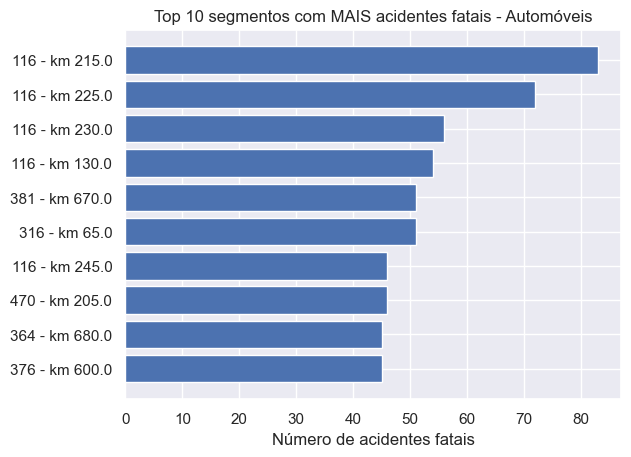

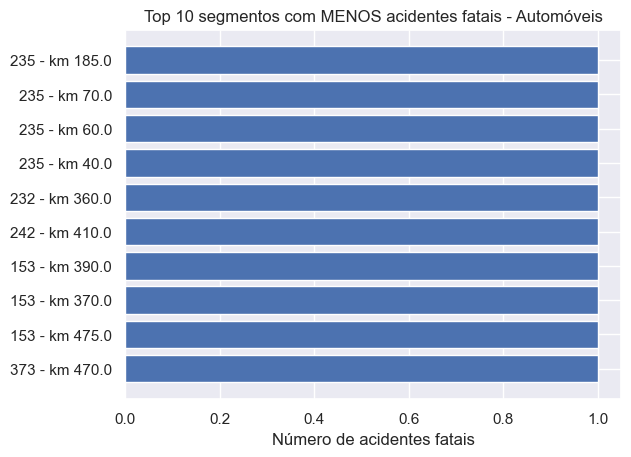

In [52]:
import matplotlib.pyplot as plt

carros_leves = ["Automóvel"]

df_mortos = df_map[df_map["mortos"] > 0].copy()
df_classe = df_mortos[df_mortos["tipo_veiculo"].isin(carros_leves)]

df_seg = df_classe.groupby(["br","km_bin"]).size().reset_index(name="n_acidentes")

df_seg["segmento"] = df_seg["br"].astype(str) + " - km " + df_seg["km_bin"].astype(str)

df_seg = df_seg.sort_values("n_acidentes", ascending=False)

top10 = df_seg.head(10)

plt.figure()
plt.barh(top10["segmento"], top10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MAIS acidentes fatais - Automóveis")
plt.gca().invert_yaxis()
plt.show()

menos10 = df_seg.tail(10).sort_values("n_acidentes")

plt.figure()
plt.barh(menos10["segmento"], menos10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MENOS acidentes fatais - Automóveis")
plt.gca().invert_yaxis()
plt.show()

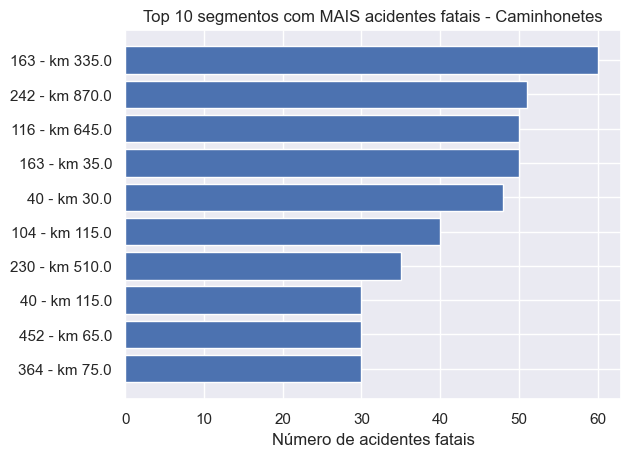

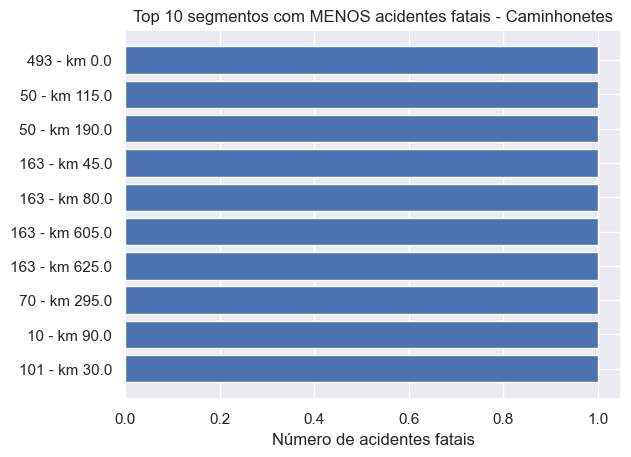

In [53]:
import matplotlib.pyplot as plt

caminhonetes = [
    "Caminhonete",
    "Camioneta",
    "Utilitário"
]

df_mortos = df_map[df_map["mortos"] > 0].copy()
df_classe = df_mortos[df_mortos["tipo_veiculo"].isin(caminhonetes)]

df_seg = df_classe.groupby(["br","km_bin"]).size().reset_index(name="n_acidentes")

df_seg["segmento"] = df_seg["br"].astype(str) + " - km " + df_seg["km_bin"].astype(str)

df_seg = df_seg.sort_values("n_acidentes", ascending=False)

top10 = df_seg.head(10)

plt.figure()
plt.barh(top10["segmento"], top10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MAIS acidentes fatais - Caminhonetes")
plt.gca().invert_yaxis()
plt.show()

menos10 = df_seg.tail(10).sort_values("n_acidentes")

plt.figure()
plt.barh(menos10["segmento"], menos10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MENOS acidentes fatais - Caminhonetes")
plt.gca().invert_yaxis()
plt.show()

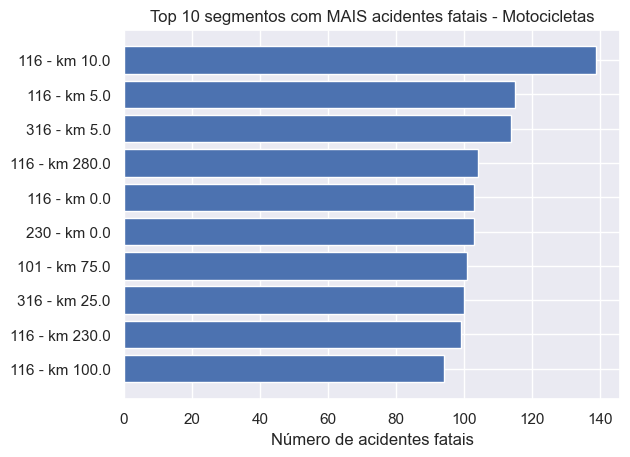

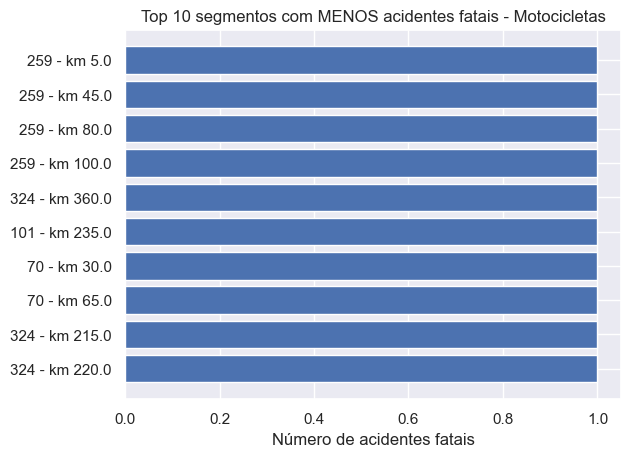

In [54]:
import matplotlib.pyplot as plt

motos = [
    "Motocicleta",
    "Motoneta"
]

df_mortos = df_map[df_map["mortos"] > 0].copy()
df_classe = df_mortos[df_mortos["tipo_veiculo"].isin(motos)]

df_seg = df_classe.groupby(["br","km_bin"]).size().reset_index(name="n_acidentes")

df_seg["segmento"] = df_seg["br"].astype(str) + " - km " + df_seg["km_bin"].astype(str)

df_seg = df_seg.sort_values("n_acidentes", ascending=False)

top10 = df_seg.head(10)

plt.figure()
plt.barh(top10["segmento"], top10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MAIS acidentes fatais - Motocicletas")
plt.gca().invert_yaxis()
plt.show()

menos10 = df_seg.tail(10).sort_values("n_acidentes")

plt.figure()
plt.barh(menos10["segmento"], menos10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MENOS acidentes fatais - Motocicletas")
plt.gca().invert_yaxis()
plt.show()

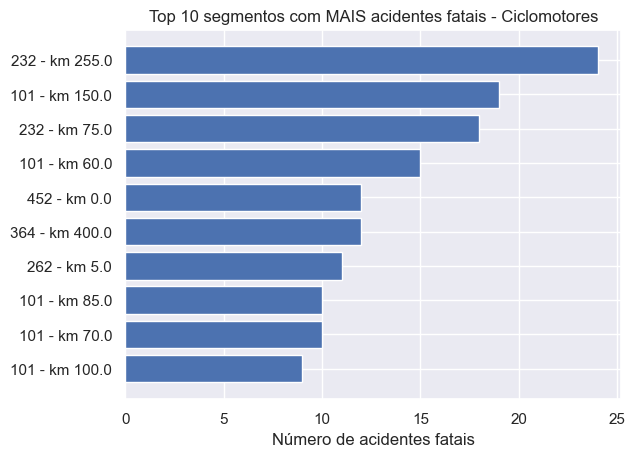

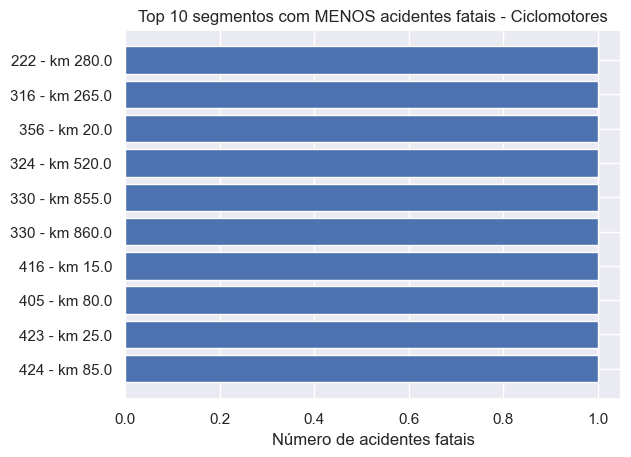

In [55]:
import matplotlib.pyplot as plt

ciclomotores = [
    "Ciclomotor",
    "Triciclo",
    "Quadriciclo"
]

df_mortos = df_map[df_map["mortos"] > 0].copy()
df_classe = df_mortos[df_mortos["tipo_veiculo"].isin(ciclomotores)]

df_seg = df_classe.groupby(["br","km_bin"]).size().reset_index(name="n_acidentes")

df_seg["segmento"] = df_seg["br"].astype(str) + " - km " + df_seg["km_bin"].astype(str)

df_seg = df_seg.sort_values("n_acidentes", ascending=False)

top10 = df_seg.head(10)

plt.figure()
plt.barh(top10["segmento"], top10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MAIS acidentes fatais - Ciclomotores")
plt.gca().invert_yaxis()
plt.show()

menos10 = df_seg.tail(10).sort_values("n_acidentes")

plt.figure()
plt.barh(menos10["segmento"], menos10["n_acidentes"])
plt.xlabel("Número de acidentes fatais")
plt.title("Top 10 segmentos com MENOS acidentes fatais - Ciclomotores")
plt.gca().invert_yaxis()
plt.show()